In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import PolynomialFeatures,MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_csv("taxi_trip_pricing.csv")
data

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049
996,45.95,Night,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,7.70,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236
998,47.56,Morning,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090


In [3]:
data.isna().sum()

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

In [4]:

data = data.dropna(subset=['Trip_Price'])

In [5]:
x = data.drop("Trip_Price",axis=1)
y= data["Trip_Price"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(x,y ,test_size=0.2)

In [7]:
Trip_Distance_km_median = X_train['Trip_Distance_km'].median()
X_train['Trip_Distance_km'] = X_train["Trip_Distance_km"].fillna(Trip_Distance_km_median)
X_test['Trip_Distance_km'] = X_test["Trip_Distance_km"].fillna(Trip_Distance_km_median)

In [41]:
X_train.isna().sum() ,X_test.isna().sum() 

(Trip_Distance_km             0
 Passenger_Count              0
 Base_Fare                    0
 Per_Km_Rate                  0
 Per_Minute_Rate              0
 Trip_Duration_Minutes        0
 Time_of_Day_Afternoon        0
 Time_of_Day_Evening          0
 Time_of_Day_Morning          0
 Time_of_Day_Night            0
 Day_of_Week Activities       0
 Day_of_Week_Weekday          0
 Day_of_Week_Weekend          0
 Traffic_Conditions_2.0       0
 Traffic_Conditions_High      0
 Traffic_Conditions_Low       0
 Traffic_Conditions_Medium    0
 Weather_Clear                0
 Weather_Rain                 0
 Weather_Snow                 0
 dtype: int64,
 Trip_Distance_km             0
 Passenger_Count              0
 Base_Fare                    0
 Per_Km_Rate                  0
 Per_Minute_Rate              0
 Trip_Duration_Minutes        0
 Time_of_Day_Afternoon        0
 Time_of_Day_Evening          0
 Time_of_Day_Morning          0
 Time_of_Day_Night            0
 Day_of_Week_Weekday     

In [9]:
Time_of_Day_mode = X_train["Time_of_Day"].mode()[0]
X_train['Time_of_Day'] = X_train["Time_of_Day"].fillna(Time_of_Day_mode)
X_test['Time_of_Day'] = X_test["Time_of_Day"].fillna(Time_of_Day_mode)

In [10]:
X_train = pd.get_dummies(X_train, columns=['Time_of_Day'], dtype=int)
X_test = pd.get_dummies(X_test, columns=['Time_of_Day'], dtype=int)

In [11]:

Day_of_Week_mode = X_train["Day_of_Week"].mode()[0]
X_train['Day_of_Week'] = X_train["Day_of_Week"].fillna(Day_of_Week_mode)
X_test['Day_of_Week'] = X_test["Day_of_Week"].fillna(Day_of_Week_mode)

In [12]:
X_train["Day_of_Week Activities"] = (X_train["Day_of_Week"] == "").astype('int8')

In [13]:
X_train = pd.get_dummies(X_train, columns=['Day_of_Week'], dtype=int)
X_test = pd.get_dummies(X_test, columns=['Day_of_Week'], dtype=int)

In [14]:
X_test


,Trip_Distance_km,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Day_of_Week_Weekday,Day_of_Week_Weekend
990,40.17,3.0,Low,Clear,3.81,0.66,0.42,62.66,0,1,0,0,1,0
885,9.75,1.0,Medium,Clear,3.89,0.99,0.30,105.81,1,0,0,0,0,1
156,33.93,2.0,Low,Rain,NaN,0.88,0.39,66.77,0,0,1,0,1,0
591,32.40,4.0,Low,Clear,4.33,1.88,0.28,13.17,0,0,0,1,0,1
174,32.61,1.0,Medium,Clear,NaN,0.70,0.31,11.91,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,28.28,2.0,Low,Rain,3.15,1.17,0.40,103.28,1,0,0,0,1,0
837,18.76,2.0,High,Clear,2.57,0.90,0.29,117.24,1,0,0,0,1,0
15,9.99,4.0,High,Clear,4.33,0.85,0.43,34.00,0,0,0,1,1,0
815,26.42,3.0,Low,Clear,4.80,1.98,0.22,16.49,0,0,0,1,0,1


In [15]:

X_train["Passenger_Count"].value_counts()
Passenger_Count_median = X_train['Passenger_Count'].median()
X_train['Passenger_Count'] = X_train["Passenger_Count"].fillna(Passenger_Count_median)
X_test['Passenger_Count'] = X_test["Passenger_Count"].fillna(Passenger_Count_median)

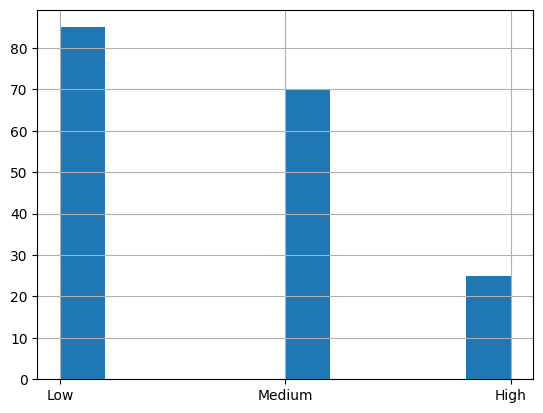

In [16]:
X_test['Traffic_Conditions'].hist()

X_train["Traffic_Conditions"].value_counts()
Traffic_Conditions_median = X_train['Passenger_Count'].median()
X_train['Traffic_Conditions'] = X_train["Traffic_Conditions"].fillna(Traffic_Conditions_median)
X_test['Traffic_Conditions'] = X_test["Traffic_Conditions"].fillna(Traffic_Conditions_median)

In [17]:
X_train = pd.get_dummies(X_train,columns=['Traffic_Conditions'], dtype=int)
X_test = pd.get_dummies(X_test,columns=['Traffic_Conditions'], dtype=int)

In [18]:
X_test

,Trip_Distance_km,Passenger_Count,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Day_of_Week_Weekday,Day_of_Week_Weekend,Traffic_Conditions_2.0,Traffic_Conditions_High,Traffic_Conditions_Low,Traffic_Conditions_Medium
990,40.17,3.0,Clear,3.81,0.66,0.42,62.66,0,1,0,0,1,0,0,0,1,0
885,9.75,1.0,Clear,3.89,0.99,0.30,105.81,1,0,0,0,0,1,0,0,0,1
156,33.93,2.0,Rain,NaN,0.88,0.39,66.77,0,0,1,0,1,0,0,0,1,0
591,32.40,4.0,Clear,4.33,1.88,0.28,13.17,0,0,0,1,0,1,0,0,1,0
174,32.61,1.0,Clear,NaN,0.70,0.31,11.91,1,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,28.28,2.0,Rain,3.15,1.17,0.40,103.28,1,0,0,0,1,0,0,0,1,0
837,18.76,2.0,Clear,2.57,0.90,0.29,117.24,1,0,0,0,1,0,0,1,0,0
15,9.99,4.0,Clear,4.33,0.85,0.43,34.00,0,0,0,1,1,0,0,1,0,0
815,26.42,3.0,Clear,4.80,1.98,0.22,16.49,0,0,0,1,0,1,0,0,1,0


In [19]:
X_train["Weather"].value_counts()

Weather_mode = X_train["Weather"].mode()[0]
X_train['Weather'] = X_train["Weather"].fillna(Weather_mode)
X_test['Weather'] = X_test["Weather"].fillna(Weather_mode)


In [20]:
X_train['Weather'].value_counts()

Weather
Clear    548
Rain     172
Snow      40
Name: count, dtype: int64

In [21]:

X_train = pd.get_dummies(X_train, columns=['Weather'], dtype=int)
X_test = pd.get_dummies(X_test, columns=['Weather'], dtype=int)

In [22]:
X_train

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Day_of_Week Activities,Day_of_Week_Weekday,Day_of_Week_Weekend,Traffic_Conditions_2.0,Traffic_Conditions_High,Traffic_Conditions_Low,Traffic_Conditions_Medium,Weather_Clear,Weather_Rain,Weather_Snow
176,34.860,4.0,3.74,1.45,0.40,21.52,0,1,0,0,0,1,0,0,0,1,0,1,0,0
170,34.200,1.0,4.55,1.02,0.41,113.92,1,0,0,0,0,1,0,0,0,1,0,1,0,0
514,3.220,3.0,3.36,NaN,0.37,34.15,0,0,1,0,0,1,0,1,0,0,0,1,0,0
356,2.300,2.0,2.43,1.44,0.26,29.64,0,0,0,1,0,0,1,0,0,1,0,1,0,0
20,30.980,1.0,4.50,0.84,0.25,57.02,1,0,0,0,0,0,1,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
783,17.940,2.0,4.14,1.43,NaN,15.13,1,0,0,0,0,1,0,0,0,1,0,0,1,0
518,49.380,1.0,3.64,1.03,0.28,9.47,0,0,1,0,0,1,0,0,0,1,0,1,0,0
769,41.240,1.0,3.91,1.03,0.38,38.26,1,0,0,0,0,1,0,0,1,0,0,1,0,0
939,25.775,2.0,3.59,0.69,0.27,87.25,0,0,1,0,0,1,0,0,0,1,0,0,1,0


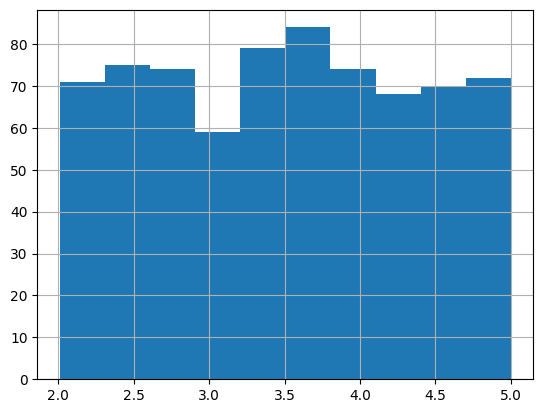

In [27]:
X_train['Base_Fare'].hist()
Base_Fare_median = X_train["Base_Fare"].median()
X_train['Base_Fare'] = X_train["Base_Fare"].fillna(Base_Fare_median)
X_test['Base_Fare'] = X_test["Base_Fare"].fillna(Base_Fare_median)


<class 'pandas.DataFrame'>
Index: 760 entries, 176 to 39
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Trip_Distance_km           760 non-null    float64
 1   Passenger_Count            760 non-null    float64
 2   Base_Fare                  760 non-null    float64
 3   Per_Km_Rate                723 non-null    float64
 4   Per_Minute_Rate            718 non-null    float64
 5   Trip_Duration_Minutes      729 non-null    float64
 6   Time_of_Day_Afternoon      760 non-null    int64  
 7   Time_of_Day_Evening        760 non-null    int64  
 8   Time_of_Day_Morning        760 non-null    int64  
 9   Time_of_Day_Night          760 non-null    int64  
 10  Day_of_Week Activities     760 non-null    int8   
 11  Day_of_Week_Weekday        760 non-null    int64  
 12  Day_of_Week_Weekend        760 non-null    int64  
 13  Traffic_Conditions_2.0     760 non-null    int64  
 14  Traffic_C

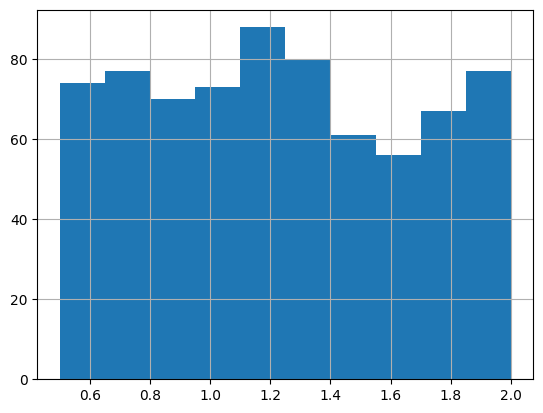

In [33]:
X_train['Per_Km_Rate'].hist()
Per_Km_Ratee_median = X_train["Per_Km_Rate"].median()
X_train['Per_Km_Rate'] = X_train["Per_Km_Rate"].fillna(Per_Km_Ratee_median)
X_test['Per_Km_Rate'] = X_test["Per_Km_Rate"].fillna(Per_Km_Ratee_median)

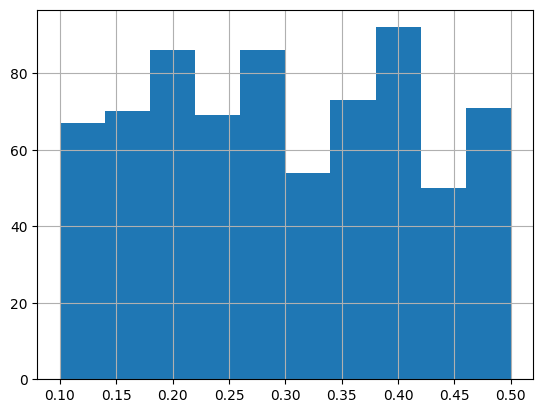

In [37]:
X_train['Per_Minute_Rate'].hist()
Per_Minute_Rate_median = X_train["Per_Minute_Rate"].median()
X_train['Per_Minute_Rate'] = X_train["Per_Minute_Rate"].fillna(Per_Minute_Rate_median)
X_test['Per_Minute_Rate'] = X_test["Per_Minute_Rate"].fillna(Per_Minute_Rate_median)

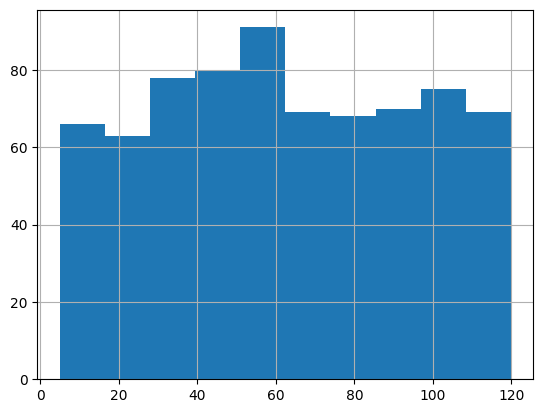

In [40]:
X_train['Trip_Duration_Minutes'].hist()
Trip_Duration_Minutes_median = X_train["Trip_Duration_Minutes"].median()
X_train['Trip_Duration_Minutes'] = X_train["Trip_Duration_Minutes"].fillna(Trip_Duration_Minutes_median)
X_test['Trip_Duration_Minutes'] = X_test["Trip_Duration_Minutes"].fillna(Trip_Duration_Minutes_median)

In [50]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [76]:
poly = PolynomialFeatures(degree=2)
poly_X_train = poly.fit_transform(X_train)
poly_X_test = poly.transform(X_test)


In [77]:
model = LinearRegression()
model.fit(poly_X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [78]:
y_pred = model.predict(poly_X_test)

In [79]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"R2 Score: {r2}")

MSE: 184.09754952664358
R2 Score: 0.9036225185975709


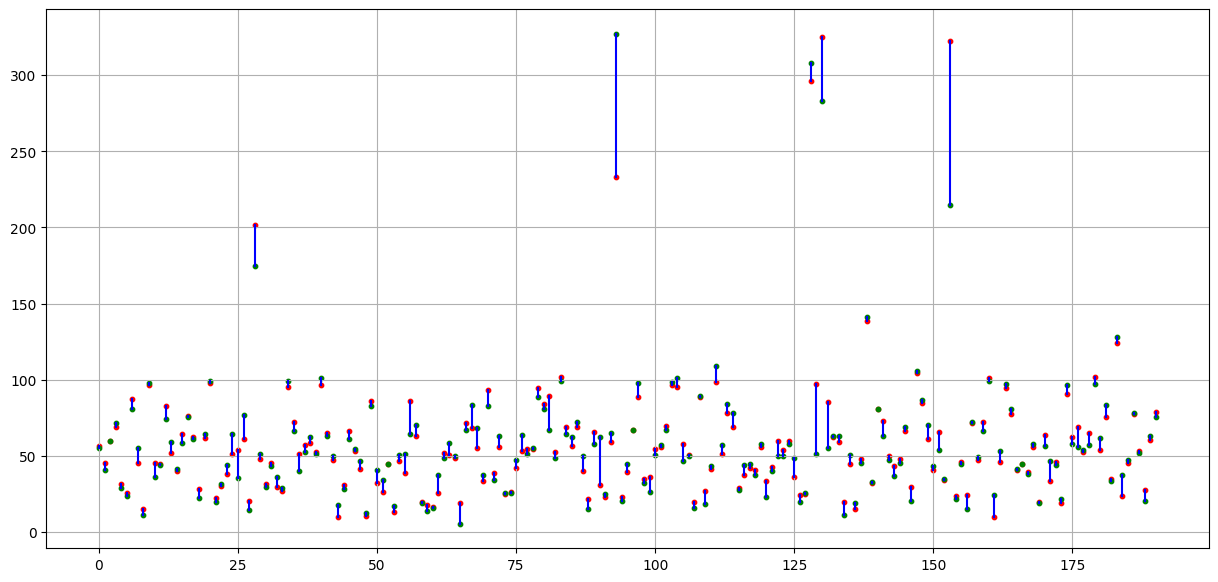

In [104]:
plt.figure(figsize=(15, 7))


plt.scatter(range(191), y_test[:191], s=10, c="r",) 
plt.scatter(range(191), y_pred[:191], s=10, c="g", ) 

for i in range(191):
    plt.plot([i,i], [y_test.iloc[i], y_pred[i]], "b")
plt.grid()
plt.show()

191

<h1>Scaeler</h1>

In [101]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
poly = PolynomialFeatures(degree=2)
poly_X_train = poly.fit_transform(X_train_scaled)
poly_X_test = poly.transform(X_test_scaled)
model = LinearRegression()
model.fit(poly_X_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [102]:
y_pred = model.predict(poly_X_test)

In [105]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"R2 Score: {r2}")

MSE: 184.09754952668777
R2 Score: 0.9036225185975477


<p>MSE: 184.09754952664358
R2 Score: 0.9036225185975709</p>
<h1>Scaler</h1>
<p>MSE: 184.09754952668777
R2 Score: 0.9036225185975477</p>

<h1>Ridge</h1>

In [128]:
ridge_model = Ridge(alpha=1)
ridge_model.fit(X_train_scaled,y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [129]:
y_pred_ridge = ridge_model.predict(X_test_scaled)

In [130]:
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge MSE: {mse_ridge}")
print(f"Ridge R2 Score: {r2_ridge}")

Ridge MSE: 244.4320556714942
Ridge R2 Score: 0.8720366134138708


<h1>Overfit</h1>

In [133]:
train_score = ridge_model.score(X_train_scaled, y_train)
test_score = ridge_model.score(X_test_scaled, y_test)
print(f"Train R2 Score: {train_score}")
print(f"Test R2 Score: {test_score}")

Train R2 Score: 0.8615008415851417
Test R2 Score: 0.8720366134138708
